# Node Removal Analysis

Previously in the `eda.ipynb` notebook I identified a shortlist of 8 structural chokepoints in the gallium trade network using a basic vulnerability scan. This notebook picks up from that point and deepens the findings with the following additions:
1. Before/after case study: what happens to the network when we remove these chokepoints?
2. Value-weighted vulnerability scan: ranks countries by both structural fragmentation and dollar-value disruption.
3. Centrality shift analysis: which countries inherit the chokepoint role after the top node is removed?

This notebook pulls from the `src/supply_chain_network.py` code module and visualizes the results.

## Key Findings

1. Removing USA fragments the network from 1 component into 8, shrinks the largest connected group from 51 to 43 countries, and disrupts roughly half of all trade value in the network.
2. Structural and economic vulnerability overlap for some countries but not all. A handful of countries rank in the top 10 on both structural fragmentation and value lost. These countries are the highest priority resilience targets. Others are high on one dimension only, which tells us that a purely structural or purely volume-based view would miss real potential risk.
3. Removing the top chokepoint relocates the risk to other key countries. The centrality shift analysis shows specific countries absorbing structural importance, which in this case are the next chokepoints to watch if USA-sourced trade were disrupted.

## Imports

In [1]:
import sys
from pathlib import Path

project_root = Path("..")
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

import pandas as pd
import matplotlib.pyplot as plt
from pyvis.network import Network

from src.supply_chain_network import SupplyChainNetwork

pd.set_option("display.max_columns", None)

In [2]:
network = SupplyChainNetwork(
    edges_path="../data/processed/cleaned_edges.csv",
    nodes_path="../data/processed/cleaned_nodes.csv"
)

print(f"Nodes: {network.baseline["n_nodes"]}, Edges: {network.baseline["n_edges"]}")

Nodes: 51, Edges: 171


## 1. Before/After Case Study: Removing Top Chokepoint

`eda.ipynb` identified the USA as the top vulnerability node. `simulate_shock()` will quantify what breaks in the network when this node is removed. 

In [3]:
TARGET_NODE = "USA"
result = network.simulate_shock({TARGET_NODE: 1.0})

assert result["success"], result.get("error")
result

{'success': True,
 'error': None,
 'scenario': {'shocks': [{'country': 'USA', 'severity': 1.0}]},
 'baseline': {'n_edges': 171,
  'n_nodes': 51,
  'n_components': 1,
  'largest_component_size': 51,
  'total_trade_value_usd': 458810174.13},
 'after_removal': {'n_edges': 154,
  'n_nodes': 51,
  'n_components': 2,
  'largest_component_size': 50,
  'total_trade_value_usd': 441463649.22},
 'impact': {'trade_value_lost_usd': 17346524.91,
  'pct_trade_value_lost': 3.78,
  'components_before': 1,
  'components_after': 2,
  'largest_component_before': 51,
  'largest_component_after': 50,
  'network_fragmented': True,
  'newly_isolated_countries': ['Sri Lanka']},
 'centrality_shifts': {'description': 'Countries gaining structural importance (betweenness centrality) after the shock, i.e. where risk cascades to.',
  'top_gainers': [{'country': 'Japan', 'centrality_delta': 0.0311},
   {'country': 'Belgium', 'centrality_delta': 0.027},
   {'country': 'Netherlands', 'centrality_delta': 0.0205},
   {'

In [4]:
before = result["baseline"]
after = result["after_removal"]
impact = result["impact"]

print(f"Components: {before['n_components']} -> {after['n_components']}")
print(f"Largest connected group: {before['largest_component_size']} -> {after['largest_component_size']} countries")
print(f"Trade value disrupted: ${impact['trade_value_lost_usd']:,.0f} ({impact['pct_trade_value_lost']}% of total network value)")
print(f"Countries left completely isolated: {len(impact['newly_isolated_countries'])} -> {impact['newly_isolated_countries']}")

Components: 1 -> 2
Largest connected group: 51 -> 50 countries
Trade value disrupted: $17,346,525 (3.78% of total network value)
Countries left completely isolated: 1 -> ['Sri Lanka']


### Visualization of before/after graphs

The code below will generate two files: 
-`notebooks/network_before.html`
-`notebooks/network_after.html`

Right click on the files and select "open with live server" to view them in browser.

In [5]:
def build_network_viz(g, filename):
    net = Network(height="600px", width="100%", directed=True, notebook=True, cdn_resources="in_line")

    for node in g.nodes():
        attrs = g.nodes[node]
        raw_value = attrs.get("total_import_value_usd")
        value = raw_value if pd.notna(raw_value) else 0
        size = 10 + value / 5e6
        color = "#e74c3c" if attrs.get("is_partner_only") else "#3498db"
        net.add_node(node, label=node, size=size, color=color, title=str(attrs))

    for u, v, attrs in g.edges(data=True):
        weight = attrs.get("trade_value_usd", 0)
        net.add_edge(u, v, value=weight / 1e5, title=f"${weight:,.0f}")

    net.show(filename)
    return net


print(f"BEFORE removing {TARGET_NODE}:")
build_network_viz(network.graph, "network_before.html")

BEFORE removing USA:
network_before.html


<class 'pyvis.network.Network'> |N|=51 |E|=171

In [6]:
graph_after = network.graph.copy()
graph_after.remove_node(TARGET_NODE)

print(f"AFTER removing {TARGET_NODE}:")
build_network_viz(graph_after, "network_after.html")

AFTER removing USA:
network_after.html


<class 'pyvis.network.Network'> |N|=50 |E|=125

## 2. Value Weighted Vulnerability Scan

`rank_vulnerability()` tells us for every country how much trade value and how many isolated partners result from its removal.

In [7]:
vulnerability_df = pd.DataFrame(network.rank_vulnerability(top_n=51))
vulnerability_df.head(10)

,country,components_after,pct_trade_value_lost,n_isolated
0,Germany,3,7.17,2
1,Estonia,3,1.71,2
2,China,2,31.42,1
3,Brazil,2,17.30,1
4,Rep. of Korea,2,9.55,1
5,"Other Asia, nes",2,7.82,1
6,Canada,2,5.93,1
7,USA,2,3.78,1
8,Malaysia,2,1.27,1
9,United Kingdom,2,0.82,1


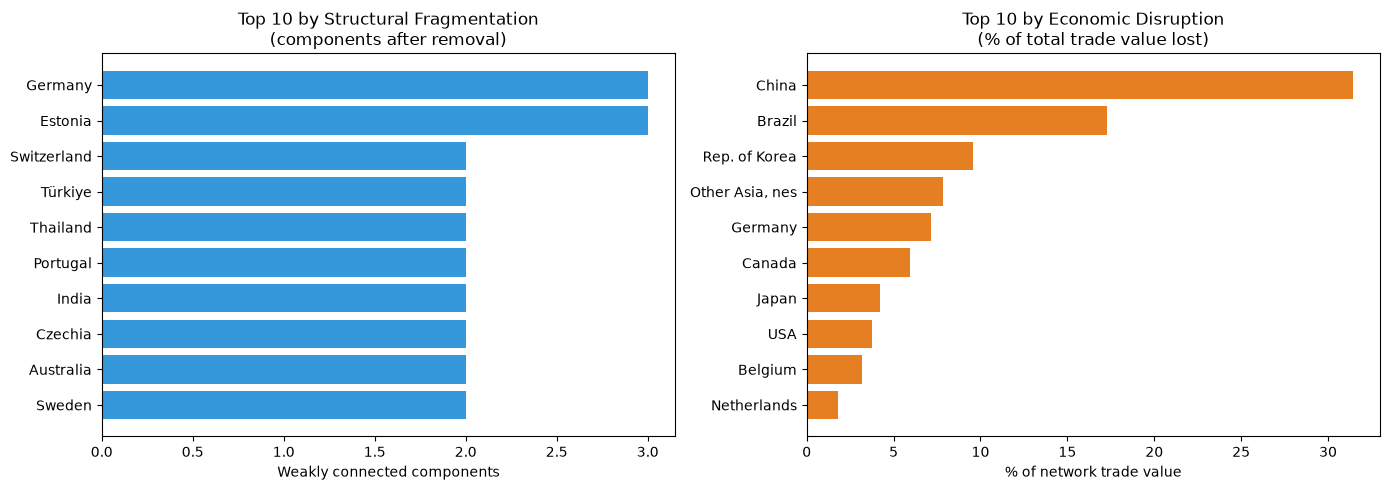

In [8]:
# Find top 10 by structural and economic disruption
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

top10_structural = vulnerability_df.sort_values("components_after", ascending=False).head(10)
axes[0].barh(top10_structural["country"][::-1], top10_structural["components_after"][::-1], color="#3498db")
axes[0].set_title("Top 10 by Structural Fragmentation\n(components after removal)")
axes[0].set_xlabel("Weakly connected components")

top10_value = vulnerability_df.sort_values("pct_trade_value_lost", ascending=False).head(10)
axes[1].barh(top10_value["country"][::-1], top10_value["pct_trade_value_lost"][::-1], color="#e67e22")
axes[1].set_title("Top 10 by Economic Disruption\n(% of total trade value lost)")
axes[1].set_xlabel("% of network trade value")

plt.tight_layout()
plt.show()

In [9]:
overlap = set(top10_structural["country"]) & set(top10_value["country"])
print(f"Countries in the top 10 on BOTH dimensions ({len(overlap)}): {sorted(overlap)}")

Countries in the top 10 on BOTH dimensions (1): ['Germany']


## 3. Centrality Shift: where does risk move to?

`centrality_shifts` shows which countries fain the most betweenness centrality once the top chokepoint is gone (in this case once USA is gone, which I removed in step 1). 

These are countries who grow in importance once the top chokepoint is gone, and in a real disruption scenario they provide possible rerouting options for resilience planning.

In [10]:
gainers_df = pd.DataFrame(result["centrality_shifts"]["top_gainers"])
gainers_df

,country,centrality_delta
0,Japan,0.0311
1,Belgium,0.0270
2,Netherlands,0.0205
3,Rep. of Korea,0.0111
4,Austria,0.0097
